# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

from tqdm import tqdm
import pickle
from typing import Union

In [2]:
import pandas as pd 
import numpy as np

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

In [4]:
from statsmodels.regression.linear_model import OLS
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from scipy.special import expit
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from scipy.optimize import minimize, minimize_scalar

In [5]:
from core.dgp import Pricing

from core.variables import * 
from core.pricing import *

# DGP

In [6]:
dgp = Pricing(seed=0)
data = dgp.sample(7866, seed=None)

train_df, test_df = train_test_split(data, test_size=0.1, random_state=0)

test_customers = test_df[[col for col in test_df.columns if col.startswith('cov_')]].values
test_prices = test_df['price'].values

# Demand Model

In [7]:
# fit model
mle_logit = MLELogit().fit(data)

print(mle_logit.evaluate(test_customers, test_prices, dgp))

{'accuracy': 0.8703939008894537, 'rmse': 0.08313481366498499}


In [8]:
# fit model
lasso_logit = LassoLogit().fit(data)

print(lasso_logit.evaluate(test_customers, test_prices, dgp))

{'accuracy': 0.9224904701397713, 'rmse': 0.047206867143519585}


In [9]:
# fit model
wlb_mle = WLBMLELogit(n_bootstraps=100).fit(data, seed=0, verbose=True)

eval_dict = wlb_mle.evaluate(test_customers, test_prices, dgp)

avg_acc, std_acc = np.mean(eval_dict['accuracy']), np.std(eval_dict['accuracy'])
avg_rmse, std_rmse = np.mean(eval_dict['rmse']), np.std(eval_dict['rmse'])

print(f'Accuracy: {avg_acc:.4f} ({avg_rmse:.4f})')
print(f'RMSE: {avg_rmse:.4f} ({std_rmse:.4f})')

100%|██████████| 100/100 [01:03<00:00,  1.59it/s]

Accuracy: 0.7597 (0.1903)
RMSE: 0.1903 (0.0080)


In [10]:
# fit model
wlb_lasso = WLBLassoLogit(n_bootstraps=100).fit(data, seed=0, verbose=True)

eval_dict = wlb_lasso.evaluate(test_customers, test_prices, dgp)

avg_acc, std_acc = np.mean(eval_dict['accuracy']), np.std(eval_dict['accuracy'])
avg_rmse, std_rmse = np.mean(eval_dict['rmse']), np.std(eval_dict['rmse'])

print(f'Accuracy: {avg_acc:.4f} ({avg_rmse:.4f})')
print(f'RMSE: {avg_rmse:.4f} ({std_rmse:.4f})')

100%|██████████| 100/100 [00:18<00:00,  5.48it/s]

Accuracy: 0.8548 (0.0939)
RMSE: 0.0939 (0.0070)


# Optimization

In [11]:
opt_prices, pricing_val = optimize(
    customers=test_customers, demand_model=dgp
)
print(f'Clairvoyant:\n Best pricing value: {pricing_val:.4f}')

opt_prices, pricing_val_est = optimize(
    customers=test_customers, demand_model=mle_logit,
)
true_pricing_val = obj_func(customers=test_customers, prices=opt_prices, demand_model=dgp)
print(f'MLE:\n Estimated pricing value: {pricing_val_est:.4f}, True pricing value: {true_pricing_val:.4f}')

opt_prices, pricing_val_est = optimize(
    customers=test_customers, demand_model=lasso_logit,
)
true_pricing_val = obj_func(customers=test_customers, prices=opt_prices, demand_model=dgp)
print(f'Lasso:\n Estimated pricing value: {pricing_val_est:.4f}, True pricing value: {true_pricing_val:.4f}')

opt_prices, pricing_val_est = optimize(
    customers=test_customers, demand_model=wlb_mle
)
true_pricing_val = obj_func(customers=test_customers, prices=opt_prices, demand_model=dgp)
print(f'WLB MLE:\n Estimated pricing value: {pricing_val_est:.4f}, True pricing value: {true_pricing_val:.4f}')

opt_prices, pricing_val_est = optimize(
    customers=test_customers, demand_model=wlb_lasso,
)
true_pricing_val = obj_func(customers=test_customers, prices=opt_prices, demand_model=dgp)
print(f'WLB Lasso:\n Estimated pricing value: {pricing_val_est:.4f}, True pricing value: {true_pricing_val:.4f}')

Clairvoyant:
 Best pricing value: 0.1051
MLE:
 Estimated pricing value: 0.2764, True pricing value: 0.0923
Lasso:
 Estimated pricing value: 0.1035, True pricing value: 0.1028
WLB MLE:
 Estimated pricing value: 1.3263, True pricing value: 0.0050
WLB Lasso:
 Estimated pricing value: 0.1044, True pricing value: 0.1034


## Visualizing objective function

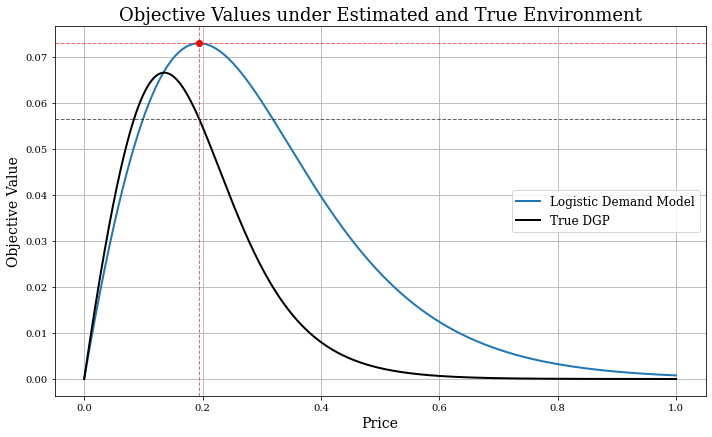

In [12]:
test_consumer = dgp.sample_individuals(1, seed=0)

price_arr = np.linspace(0, 1, 1000)

ldm_obj_val_arr = np.array([obj_func(test_consumer, np.array([price]), lasso_logit) for price in price_arr])
plugin_price, plugin_obj_val = optimize(test_consumer, lasso_logit)
actual_obj_val = obj_func(test_consumer, plugin_price, dgp)
plugin_price = plugin_price[0]

dgp_obj_val_arr = np.array([obj_func(test_consumer, np.array([price]), dgp) for price in price_arr])

fig, ax = plt.subplots(figsize=(10, 6.18))

# 
ax.plot(price_arr, ldm_obj_val_arr, color='C0', lw=2, label='Logistic Demand Model')
ax.plot(plugin_price, plugin_obj_val, 'ro', markersize=6)

# 
ax.plot(price_arr, dgp_obj_val_arr, color='black', lw=2, label='True DGP')

# plot plugin price and its performances
ax.axvline(plugin_price, color='red', linestyle='--', lw=1, alpha=0.6)
ax.axhline(plugin_obj_val, color='red', linestyle='--', lw=1, alpha=0.6)
ax.axhline(actual_obj_val, color='black', linestyle='--', lw=1, alpha=0.6)

ax.set_xlabel('Price', fontsize=axis_label_size)
ax.set_ylabel('Objective Value', fontsize=axis_label_size)
ax.set_title('Objective Values under Estimated and True Environment', fontsize=title_size)

plt.legend(fontsize=legend_label_size)
plt.grid()
plt.tight_layout()
plt.show()

# Winner's Curse

In [43]:
def repeated_experiments(
    data_params: dict, 
    experiment_params: dict, 
    estimators_dict: dict, 
    verbose: bool = False, 
) -> list:
    # extract parameters
    n_experiments = experiment_params['n_experiments']
    is_in_sample = experiment_params['in_sample']
    demand_model = experiment_params['demand_model']
    sample_size = data_params['sample_size']
    n_customers = data_params['n_customers']

    # create data generation process
    dgp = Pricing(seed=0)

    # placeholder for results
    result_list = [None] * n_experiments

    # if verbose is true, use tqdm for for loop
    iterator = tqdm(range(n_experiments)) if verbose else range(n_experiments)
    for experiment_id in iterator:
        # generate data
        data = dgp.sample(sample_size, seed=experiment_id)

        if is_in_sample:
            target_customers = data[[col for col in test_df.columns if col.startswith('cov_')]].values
        else:
            target_customers = dgp.sample_individuals(n_customers, seed=10 * experiment_id)

        # estimate demand model
        dm = demand_model_dict[demand_model]().fit(data)

        # optimize prices
        plugin_prices, pricing_val_est = optimize(
            customers=target_customers, demand_model=dm
        )
        
        # calculate the actual value of the plugin targeting policy
        true_pricing_val = obj_func(
            customers=target_customers, 
            prices=plugin_prices, 
            demand_model=dgp
        )

        # bookkeeping
        result_list[experiment_id] = {
            'plugin_pricing_val_est': pricing_val_est, 
            'true_plugin_pricing_val': true_pricing_val,
            'plugin_wc': pricing_val_est - true_pricing_val, 
            'plugin_wc_pct': (pricing_val_est - true_pricing_val) / true_pricing_val
        }

        # run all remaining estimators
        for name in estimators_dict.keys():
            temp_targ_val_est = estimators_dict[name]['estimator'](
                data=data, 
                target_customers=target_customers, 
                demand_model=demand_model, 
                **estimators_dict[name]['params']
            )

            # bookkeeping 
            result_list[experiment_id].update({
                f'{name}_targ_val_est': temp_targ_val_est, 
                f'{name}_wc': temp_targ_val_est - true_pricing_val, 
                f'{name}_wc_pct': (temp_targ_val_est - true_pricing_val) / true_pricing_val, 
            })

    return result_list

In [14]:
data_params = {'sample_size': 7866, 'n_customers': 100}
experiment_params = {'n_experiments': 100, 'in_sample': False, 'demand_model': 'mle'}

estimators_dict = {}

result_records = repeated_experiments(
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True
)

mle_emp_wc_dstn_arr = np.array([record['plugin_wc'] for record in result_records])
mle_emp_wc_pct_dstn_arr = 100 * np.array([record['plugin_wc_pct'] for record in result_records])
avg_mle_emp_wc_pct = mle_emp_wc_pct_dstn_arr.mean()
se_mle_emp_wc_pct = mle_emp_wc_pct_dstn_arr.std() / np.sqrt(mle_emp_wc_pct_dstn_arr.size)

print(f"Winner's Curse: {avg_mle_emp_wc_pct:.4f}% ({se_mle_emp_wc_pct:.4f}%)")

100%|██████████| 100/100 [00:44<00:00,  2.23it/s]

Winner's Curse: 248.6066% (20.1795%)


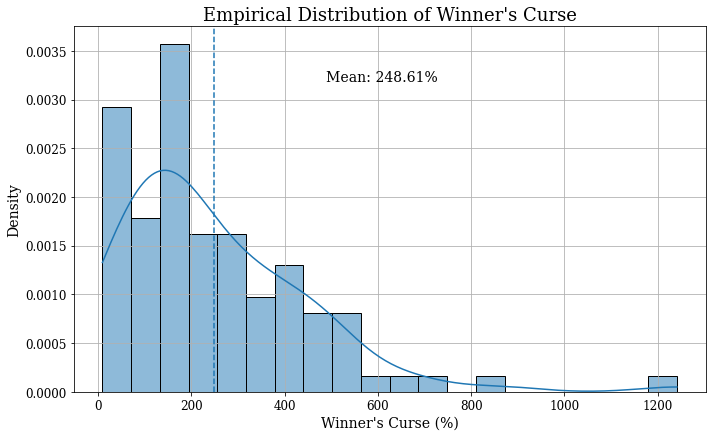

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(mle_emp_wc_pct_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C0')
ax.axvline(mle_emp_wc_pct_dstn_arr.mean(), color='C0', linestyle='--')
ax.annotate(
    f"Mean: {mle_emp_wc_pct_dstn_arr.mean():.2f}%", 
    xy=(0.4, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)

ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
# plt.savefig('figures/case1-winners-curse-dstn.png')
plt.show()

In [16]:
data_params = {'sample_size': 7866, 'n_customers': 100}
experiment_params = {'n_experiments': 100, 'in_sample': False, 'demand_model': 'lasso'}

estimators_dict = {}

result_records = repeated_experiments(
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True
)

lasso_emp_wc_dstn_arr = np.array([record['plugin_wc'] for record in result_records])
lasso_emp_wc_pct_dstn_arr = 100 * np.array([record['plugin_wc_pct'] for record in result_records])
avg_lasso_emp_wc_pct = lasso_emp_wc_pct_dstn_arr.mean()
se_lasso_emp_wc_pct = lasso_emp_wc_pct_dstn_arr.std() / np.sqrt(lasso_emp_wc_pct_dstn_arr.size)

print(f"Winner's Curse: {avg_lasso_emp_wc_pct:.4f}% ({se_lasso_emp_wc_pct:.4f}%)")

100%|██████████| 100/100 [00:19<00:00,  5.09it/s]

Winner's Curse: 9.5760% (0.6794%)


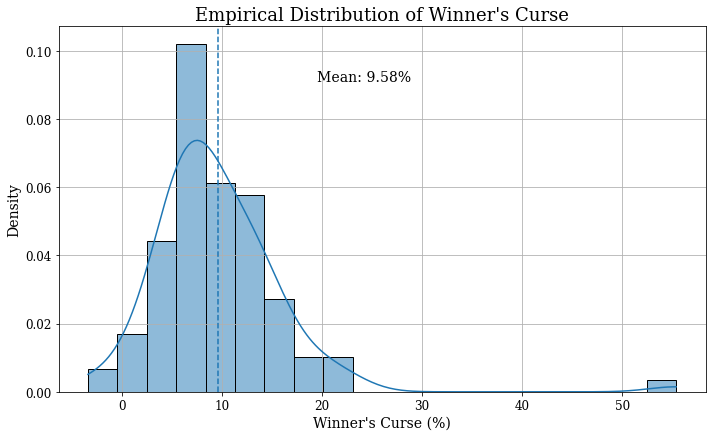

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(lasso_emp_wc_pct_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C0')
ax.axvline(lasso_emp_wc_pct_dstn_arr.mean(), color='C0', linestyle='--')
ax.annotate(
    f"Mean: {lasso_emp_wc_pct_dstn_arr.mean():.2f}%", 
    xy=(0.4, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)

ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
# plt.savefig('figures/case1-winners-curse-dstn.png')
plt.show()

In [ ]:
data_params = {'sample_size': 7866, 'n_customers': 100}
experiment_params = {'n_experiments': 100, 'in_sample': False, 'demand_model': 'wlb'}

estimators_dict = {}

result_records = repeated_experiments(
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True
)

wlb_emp_wc_dstn_arr = np.array([record['plugin_wc'] for record in result_records])
wlb_emp_wc_pct_dstn_arr = 100 * np.array([record['plugin_wc_pct'] for record in result_records])
avg_wlb_emp_wc_pct = wlb_emp_wc_pct_dstn_arr.mean()
se_wlb_emp_wc_pct = wlb_emp_wc_pct_dstn_arr.std() / np.sqrt(wlb_emp_wc_pct_dstn_arr.size)

print(f"Winner's Curse: {avg_wlb_emp_wc_pct:.4f}% ({se_wlb_emp_wc_pct:.4f}%)")

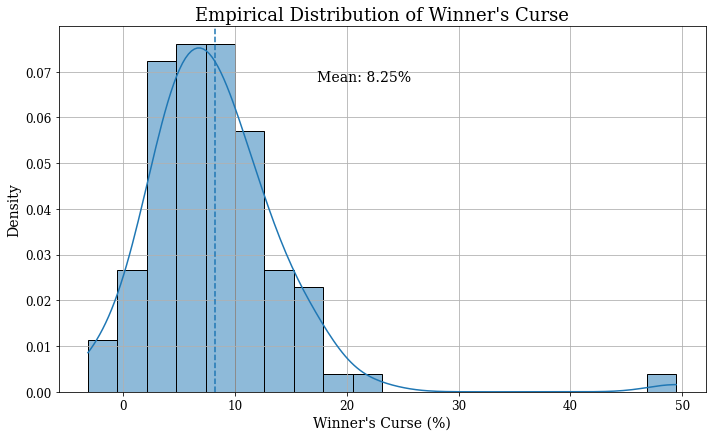

In [86]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wlb_emp_wc_pct_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C0')
ax.axvline(wlb_emp_wc_pct_dstn_arr.mean(), color='C0', linestyle='--')
ax.annotate(
    f"Mean: {wlb_emp_wc_dstn_arr.mean():.2f}%", 
    xy=(0.4, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)

ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
# plt.savefig('figures/case1-winners-curse-dstn.png')
plt.show()

# Estimating Winner's Curse

## Standard Bootstrap

In [73]:
def get_wc_boot_dstn(
    data: pd.DataFrame, target_customers: np.ndarray,
    demand_model: str, n_bootstraps: int = 500, 
    verbose: bool = False, **kwargs
) -> np.ndarray:
    # attributes
    sample_size = data.shape[0]

    # placeholder for the bootstrap distribution of winner's curse
    boot_wc_dstn_arr = np.zeros(shape=(n_bootstraps, ))

    # fit demand model with all data
    emp_dm = demand_model_dict[demand_model]().fit(data)

    # create bootstrap distribution
    iterator = tqdm(range(n_bootstraps)) if verbose else range(n_bootstraps)
    for boot_id in iterator:
        # bootstrap data
        boot_data = data.sample(sample_size, replace=True)

        # estimate the treatment effect table from table
        boot_dm = demand_model_dict[demand_model]().fit(boot_data)

        # optimize
        boot_prices, boot_pricing_val_est = optimize(
            customers=target_customers, demand_model=boot_dm
        )

        # evaluate boot_targ_decision with empirical treatment effects
        emp_boot_pricing_val_est = obj_func(
            customers=target_customers, 
            prices=boot_prices, 
            demand_model=emp_dm
        )

        # calculate the winner's curse
        boot_wc_dstn_arr[boot_id] = boot_pricing_val_est - emp_boot_pricing_val_est

    return boot_wc_dstn_arr

In [21]:
boot_wc_dstn_arr = get_wc_boot_dstn(
    data=train_df, target_customers=test_customers, 
    demand_model='lasso', 
    n_bootstraps=500, verbose=True
)

100%|██████████| 500/500 [02:59<00:00,  2.78it/s]


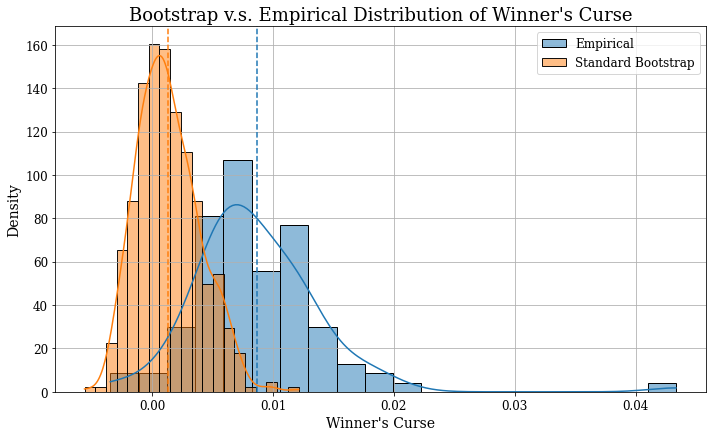

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(lasso_emp_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(lasso_emp_wc_dstn_arr.mean(), color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C1', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='upper right', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [35]:
def get_wc_m_out_of_n_boot_dstn(
    data: pd.DataFrame, target_customers: np.ndarray,
    demand_model: str, 
    n_bootstraps: int = 500, power: float = 0.90, 
    verbose: bool = False, seed: int = None, 
    **kwargs
) -> np.ndarray:
    # parameter checks
    assert 0 < power < 1, 'Power should be between 0 and 1.' 

    # set seed
    if seed is not None:
        np.random.seed(seed)

    # attributes
    sample_size = data.shape[0]
    m = int(sample_size ** power)  # bootstrap sample size

    # placeholder for the bootstrap distribution of winner's curse
    boot_wc_dstn_arr = np.zeros(shape=(n_bootstraps, ))

    # fit demand model with all data
    emp_dm = demand_model_dict[demand_model]().fit(data)

    # create bootstrap distribution
    iterator = tqdm(range(n_bootstraps)) if verbose else range(n_bootstraps)
    for boot_id in iterator:
        # bootstrap data
        boot_data = data.sample(m, replace=True)

        # estimate the treatment effect table from table
        boot_dm = demand_model_dict[demand_model]().fit(boot_data)

        # optimize
        boot_prices, boot_pricing_val_est = optimize(
            customers=target_customers, demand_model=boot_dm
        )

        # evaluate boot_targ_decision with empirical treatment effects
        emp_boot_pricing_val_est = obj_func(
            customers=target_customers, 
            prices=boot_prices, 
            demand_model=emp_dm
        )

        # calculate the winner's curse
        boot_wc_dstn_arr[boot_id] = boot_pricing_val_est - emp_boot_pricing_val_est

    return boot_wc_dstn_arr[~np.isnan(boot_wc_dstn_arr)]

In [34]:
mn_boot_wc_dstn_arr = get_wc_m_out_of_n_boot_dstn(
    data=train_df, target_customers=test_customers, 
    demand_model='lasso', power=0.87, 
    n_bootstraps=500, verbose=True
)

100%|██████████| 500/500 [02:25<00:00,  3.43it/s]


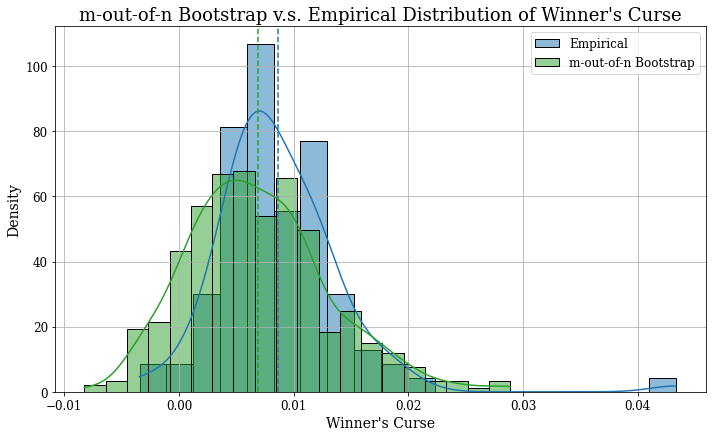

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(lasso_emp_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(lasso_emp_wc_dstn_arr.mean(), color='C0', linestyle='--')

sns.histplot(mn_boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap')
ax.axvline(mn_boot_wc_dstn_arr.mean(), color='C2', linestyle='--')

ax.set_title("m-out-of-n Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='upper right', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [36]:
def get_wc_num_boot_dstn(
    data: pd.DataFrame, target_customers: np.ndarray, 
    demand_model: str, 
    n_bootstraps: int = 500, power: float = -0.45, 
    verbose: bool = False, seed: int = None, 
    **kwargs
):
    # parameter checks
    assert 0 > power > -0.5, "Power must be between 0 and -0.5"

    # set seed
    if seed is not None:
        np.random.seed(seed)

    # attributes
    sample_size = data.shape[0]
    epsilon_n = sample_size ** power  # epsilon_n

    # placeholder for the bootstrap distribution of winner's curse
    boot_wc_dstn_arr = np.zeros(shape=(n_bootstraps, ))

    # fit demand model with all data
    emp_dm = demand_model_dict[demand_model]().fit(data)

    # create bootstrap distribution
    iterator = tqdm(range(n_bootstraps)) if verbose else range(n_bootstraps)
    for boot_id in iterator:
        # bootstrap data
        boot_data = data.sample(sample_size, replace=True)

        # estimate the treatment effect table from table
        boot_dm = demand_model_dict[demand_model]().fit(boot_data)

        # optimize
        boot_prices, boot_pricing_val_est = optimize(
            customers=target_customers, demand_model=boot_dm
        )

        # predict purchase probabilities under empirical model and bootstrapped model
        emp_purchase_prob = emp_dm.predict_proba(target_customers, boot_prices)
        boot_purchase_prob = boot_dm.predict_proba(target_customers, boot_prices)

        # error
        norm_error = np.sqrt(sample_size) * (boot_purchase_prob - emp_purchase_prob)

        # calculate perturbation
        perturb_purchase_prob = emp_purchase_prob + epsilon_n * norm_error

        # evaluate boot_price with perturbed purchase probabilities
        perturb_val_est = obj_func_with_purchase_proba(
            prices=boot_prices, purchase_proba=perturb_purchase_prob
        )

        # evaluate boot_price with empirical purchase probabilities
        emp_val_est = obj_func_with_purchase_proba(
            prices=boot_prices, purchase_proba=emp_purchase_prob
        )

        # calculate the winner's curse
        boot_wc_dstn_arr[boot_id] = perturb_val_est - emp_val_est

    return boot_wc_dstn_arr

In [28]:
num_boot_wc_dstn_arr = get_wc_num_boot_dstn(
    data=train_df, target_customers=dgp.sample_individuals(1, seed=5), 
    demand_model='lasso', n_bootstraps=500, power=-0.45, verbose=True
)

100%|██████████| 500/500 [01:01<00:00,  8.17it/s]


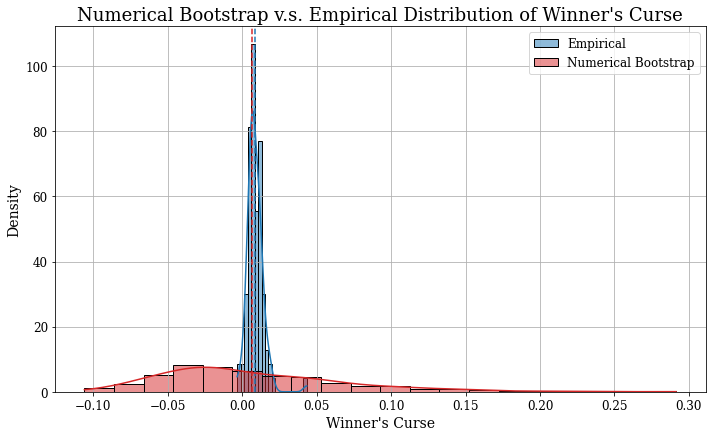

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(lasso_emp_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(lasso_emp_wc_dstn_arr.mean(), color='C0', linestyle='--')

sns.histplot(num_boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C3', label='Numerical Bootstrap')
ax.axvline(num_boot_wc_dstn_arr.mean(), color='C3', linestyle='--')

ax.set_title("Numerical Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='upper right', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Bootstrap Correction

In [71]:
def bootstrap_correction_estimate(
    data: pd.DataFrame, target_customers: np.ndarray,
    demand_model: str, 
    bootstrap_method: str = 'standard', n_bootstraps: int = 500, 
    verbose: bool = False,
    **kwargs
) -> np.ndarray:
    # estimation
    emp_dm = demand_model_dict[demand_model]().fit(data)

    # solve the plugin problem
    _, plugin_pricing_val_est = optimize(
        customers=target_customers, demand_model=emp_dm
    )

    # dictionary of available bootstrap methods
    boot_methods_dict = {
        'standard': get_wc_boot_dstn, 
        'm_out_of_n': get_wc_m_out_of_n_boot_dstn, 
        'numerical': get_wc_num_boot_dstn, 
    }

    # get the bootstrap distribution of winner' curse
    boot_wc_dstn_arr = boot_methods_dict[bootstrap_method](
        data=data, target_customers=target_customers, 
        demand_model=demand_model, 
        n_bootstraps=n_bootstraps, verbose=False, 
        **kwargs
    )

    return plugin_pricing_val_est - boot_wc_dstn_arr.mean()

In [74]:
data_params = {'sample_size': 5000, 'n_customers': 100}
experiment_params = {'n_experiments': 100, 'in_sample': False, 'demand_model': 'lasso'}

estimators_dict = {
    'bootstrap_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 100}
    }, 
    'mn_boot_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.9}
    }, 
    'num_boot_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45}
    }
}

result_records = repeated_experiments(
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True
)

100%|██████████| 100/100 [52:12<00:00, 31.33s/it]


plugin: 12.80% (0.11%)
bootstrap_correction: 11.16% (0.11%)
mn_boot_correction: -1.25% (0.07%)
num_boot_correction: 10.21% (0.11%)


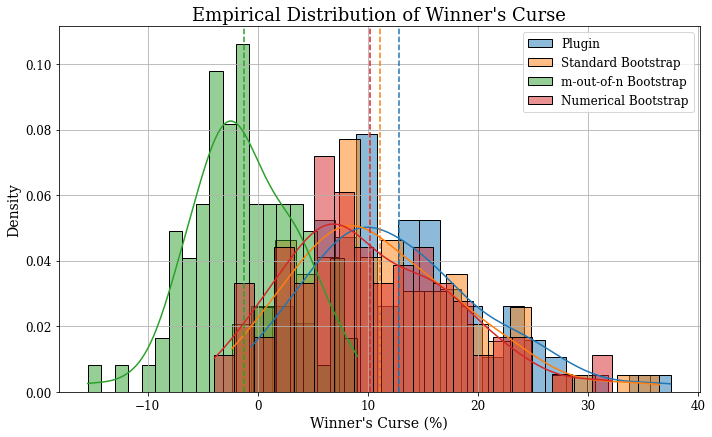

In [81]:
result_df = pd.DataFrame.from_records(result_records)
wc_df = 100 * result_df[[col for col in result_df.columns if col.endswith('wc_pct')]].copy()
wc_df.rename(columns={col: col.replace('_wc_pct', '') for col in wc_df.columns}, inplace=True)

# print
for col in wc_df.columns:
    avg_wc = wc_df[col].mean()
    se_wc = wc_df[col].std() / np.sqrt(data_params['sample_size'])

    print(f"{col}: {avg_wc:.2f}% ({se_wc:.2f}%)")

# plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_df['plugin'], bins=20, kde=True, stat='density', ax=ax, color='C0', label='Plugin')
ax.axvline(wc_df['plugin'].mean(), color='C0', linestyle='--')

sns.histplot(wc_df['bootstrap_correction'], bins=20, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap')
ax.axvline(wc_df['bootstrap_correction'].mean(), color='C1', linestyle='--')

sns.histplot(wc_df['mn_boot_correction'], bins=20, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap')
ax.axvline(wc_df['mn_boot_correction'].mean(), color='C2', linestyle='--')

sns.histplot(wc_df['num_boot_correction'], bins=20, kde=True, stat='density', ax=ax, color='C3', label='Numerical Bootstrap')
ax.axvline(wc_df['num_boot_correction'].mean(), color='C3', linestyle='--')

ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='upper right', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

In [324]:
dgp = PricingDGP(seed=0)
data = dgp.sample(1000, seed=4)
test_customer = dgp.sample_individuals(1, seed=4)

In [325]:
m = int(1000 ** 0.9)

In [345]:
for _ in range(1000):
    # bootstrap data
    boot_data = data.sample(m, replace=True)

    # estimate the treatment effect table from table
    boot_ldm = LogisticDemandModel().fit(boot_data)

    # optimize
    boot_decision, boot_targ_val_est = optimize(test_customer, boot_ldm)

    if ~np.isnan(boot_decision) and boot_targ_val_est > 100:
        print('Found Error')
        break

Found Error


In [380]:
opt_result = minimize(
    fun=lambda x: -objective_func(test_customer, x, boot_ldm),
    x0=np.random.uniform(size=test_customer.shape[0]),
    bounds=[(0, np.nan) for _ in range(test_customer.shape[0])],
    method='L-BFGS-B', 
)
opt_result

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: -45253410.76461691
        x: [ 1.173e+08]
      nit: 2
      jac: [ 0.000e+00]
     nfev: 6
     njev: 3
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>

In [395]:
boot_data

,choice,price,cov_0,cov_1,cov_2,cov_3,cov_4,cov_5,cov_6,cov_7,...,cov_123,cov_124,cov_125,cov_126,cov_127,cov_128,cov_129,cov_130,cov_131,cov_132
913,1.0,0.345276,0.162994,0.036072,0.135381,0.150589,0.045581,0.052802,0.062523,0.225397,...,0.024754,0.021330,0.097890,0.037984,0.077314,0.026165,0.008562,0.029767,0.005566,0.002287
222,1.0,0.011641,0.140919,0.005933,0.048402,0.035142,0.189995,0.091197,0.085504,0.357977,...,0.066612,0.029928,0.003554,0.017190,0.047767,0.036266,0.018125,0.008946,0.019708,0.005595
112,1.0,0.017027,0.047339,0.078129,0.153352,0.014271,0.024508,0.080029,0.094079,0.220206,...,0.097531,0.101356,0.061418,0.078764,0.129093,0.016926,0.043400,0.007935,0.026680,0.059570
240,1.0,0.419692,0.191265,0.085678,0.034427,0.082950,0.116609,0.079432,0.152903,0.169582,...,0.048040,0.135534,0.001065,0.020246,0.083762,0.009697,0.011652,0.102299,0.100048,0.031943
28,1.0,0.170274,0.030329,0.084136,0.077726,0.119506,0.152770,0.051231,0.218438,0.094943,...,0.219543,0.073082,0.068797,0.013277,0.012757,0.008868,0.072336,0.019722,0.002199,0.015153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
524,0.0,0.380915,0.002508,0.035394,0.127479,0.167984,0.046464,0.060930,0.052645,0.090153,...,0.015506,0.091438,0.036591,0.058823,0.045137,0.014338,0.010671,0.012438,0.063771,0.029467
273,1.0,0.061881,0.070952,0.083836,0.008417,0.153222,0.017121,0.130984,0.125016,0.024578,...,0.018187,0.048127,0.061127,0.008771,0.175809,0.026718,0.004503,0.088186,0.157091,0.048918
710,1.0,0.222104,0.433319,0.380792,0.375455,0.515963,0.479210,0.579868,0.265289,0.363965,...,0.042796,0.065651,0.060388,0.043253,0.089174,0.111211,0.002646,0.039333,0.055934,0.026945
583,0.0,0.223674,0.048620,0.199700,0.341339,0.073167,0.265274,0.009169,0.062063,0.225657,...,0.096812,0.040204,0.133795,0.069067,0.105559,0.033144,0.049075,0.099842,0.008109,0.062809


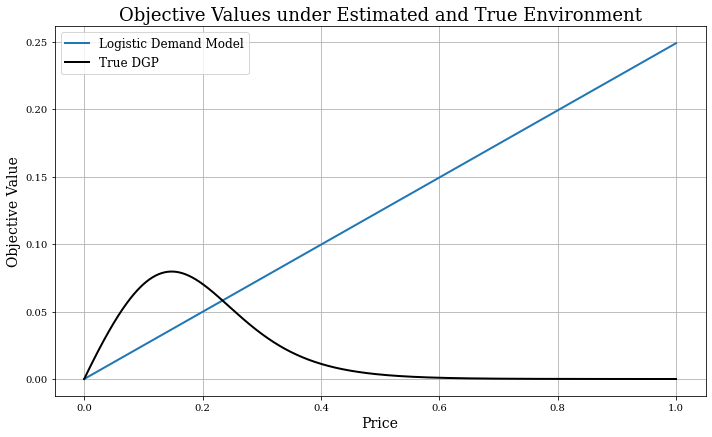

In [386]:
price_arr = np.linspace(0, 1, 1000)

ldm_obj_val_arr = np.array([objective_func(test_consumer, price, boot_ldm) for price in price_arr])
dgp_obj_val_arr = np.array([objective_func(test_consumer, price, dgp) for price in price_arr])

fig, ax = plt.subplots(figsize=(10, 6.18))

# 
ax.plot(price_arr, ldm_obj_val_arr, color='C0', lw=2, label='Logistic Demand Model')

# 
ax.plot(price_arr, dgp_obj_val_arr, color='black', lw=2, label='True DGP')

ax.set_xlabel('Price', fontsize=axis_label_size)
ax.set_ylabel('Objective Value', fontsize=axis_label_size)
ax.set_title('Objective Values under Estimated and True Environment', fontsize=title_size)

plt.legend(fontsize=legend_label_size)
plt.grid()
plt.tight_layout()
plt.show()